# Projet TensorFlow — Prédiction de la consommation énergétique d'un bâtiment

**Objectif :** construire, avec **TensorFlow/Keras**, un réseau de neurones capable de prédire la **consommation énergétique** d'un bâtiment à partir de sa température, de son humidité et de son nombre d'occupants.

C'est un problème de **régression** (prédiction d'une valeur numérique continue), à la différence de l'atelier Scikit-learn qui traitait une classification.

**Workflow suivi :**
`Génération des données → X/y → Train/Test → Modèle → Compilation → Entraînement → Évaluation → Prédiction → Sauvegarde → Chargement → Fonction d'inférence`

Structure du projet :
```
Tensorflow_Iot_Energy_Prediction/
├── notebooks/Tensorflow_Iot_Energy_Prediction.ipynb
└── models/modele_consommation.keras
```


### Installation et imports

`tensorflow` fournit Keras pour construire et entraîner le réseau de neurones ; `numpy` sert à générer et manipuler les données ; `matplotlib` à visualiser l'apprentissage et les résultats.

In [1]:
# Installation si nécessaire
!pip install tensorflow matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Version de TensorFlow :", tf.__version__)


  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.6/351.2 MB 8.6 MB/s eta 0:00:41
   ---------------------------------------- 2.6/351.2 MB 6.2 MB/s eta 0:00:57
   ---------------------------------------- 3.4/351.2 MB 5.3 MB/s eta 0:01:06
   ---------------------------------------- 4.2/351.2 MB 4.4 MB/s eta 0

## Partie 1 : Génération du dataset

Aucun fichier n'est fourni ici : on **simule** un jeu de données réaliste avec NumPy, en combinant des lois statistiques plausibles (normale, uniforme, entière) et une formule physique bruitée — une pratique courante pour prototyper un modèle avant d'avoir accès à de vraies données de production.

In [3]:
# Graine fixée pour la reproductibilité
rng = np.random.default_rng(seed=42)
n = 1000

# 1a) Température : loi normale (moyenne 25°C, écart-type 4°C)
temperature = rng.normal(loc=25, scale=4, size=n)

# 1b) Humidité : loi uniforme entre 30% et 80%
humidite = rng.uniform(30, 80, size=n)

# 1c) Occupants : entiers entre 1 et 49 inclus
occupants = rng.integers(1, 50, size=n)  # borne haute exclue -> 50 pour inclure 49

print("Température (extrait) :", temperature[:5].round(2))
print("Humidité (extrait) :", humidite[:5].round(2))
print("Occupants (extrait) :", occupants[:5])


Température (extrait) : [26.22 20.84 28.   28.76 17.2 ]
Humidité (extrait) : [62.35 47.12 50.41 52.   36.29]
Occupants (extrait) : [ 5 39 41 47 16]


In [4]:
# 2) Consommation, selon la formule donnée + bruit aléatoire (imprévus, facteurs non mesurés)
bruit = rng.normal(loc=0, scale=10, size=n)

consommation = (
    50
    + 5 * temperature
    + 1.5 * humidite
    + 4 * occupants
    + bruit
)

print("Consommation (extrait) :", consommation[:5].round(2))


Consommation (extrait) : [285.81 383.05 429.26 458.81 253.27]


In [5]:
# 3) Matrice des caractéristiques X (1000 x 3), au format float32
X = np.column_stack([temperature, humidite, occupants]).astype(np.float32)

# 4) Cible y, au format float32
y = consommation.astype(np.float32)

print("Shape de X :", X.shape, "| dtype :", X.dtype)
print("Shape de y :", y.shape, "| dtype :", y.dtype)


Shape de X : (1000, 3) | dtype : float32
Shape de y : (1000,) | dtype : float32


## Partie 2 : Découpage Train/Test

Comme pour tout modèle supervisé, on réserve une partie des données (jamais vue pendant l'entraînement) pour évaluer honnêtement la capacité du réseau à généraliser.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42      # reproductibilité du découpage
)

print("Taille X_train :", X_train.shape, "| Taille X_test :", X_test.shape)


Taille X_train : (800, 3) | Taille X_test : (200, 3)


## Partie 3 : Création du modèle

On construit un réseau de neurones **séquentiel** (couches empilées les unes après les autres). Les couches cachées utilisent l'activation **ReLU** (standard pour les couches intermédiaires), la couche de sortie n'a **qu'un seul neurone sans activation** car on prédit une valeur numérique continue (régression), pas une probabilité.

In [7]:
modele = keras.Sequential([
    layers.Input(shape=(3,)),                  # 3 caractéristiques en entrée : température, humidité, occupants
    layers.Dense(16, activation="relu"),        # couche 1 : 16 neurones, ReLU
    layers.Dense(8, activation="relu"),         # couche 2 : 8 neurones, ReLU
    layers.Dense(1)                              # couche 3 : 1 neurone, sortie = consommation prédite
])

# 2) Résumé de l'architecture
modele.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

## Partie 4 : Compilation du modèle

La compilation définit **comment** le modèle va apprendre : l'**optimiseur** (méthode d'ajustement des poids), la **fonction de perte** (mesure de l'erreur à minimiser, adaptée à la régression) et une **métrique** de suivi, ici l'erreur absolue moyenne (MAE), plus facile à interpréter que la perte brute (elle s'exprime dans la même unité que la consommation).

In [8]:
modele.compile(
    optimizer="adam",              # méthode d'ajustement des poids
    loss="mean_squared_error",      # erreur de prédiction (MSE, adaptée à la régression)
    metrics=["mae"]                 # erreur absolue moyenne, suivie en complément
)


## Partie 5 : Entraînement du modèle

L'entraînement ajuste itérativement les poids du réseau pour minimiser l'erreur. Une partie du train (`validation_split`) est mise de côté à chaque époque pour surveiller si le modèle apprend correctement sans sur-apprendre (*overfitting*).

In [9]:
# 1) Entraînement : 20% du train en validation, 50 époques, batch de 16
history = modele.fit(
    X_train, y_train,
    validation_split=0.2,   # 20% des données d'entraînement pour la validation
    epochs=50,                # 50 passages sur les données
    batch_size=16,             # 16 observations traitées à la fois
    verbose=0
)

print("Entraînement terminé.")


Entraînement terminé.


In [10]:
# 2) Contenu de history
print("Clés disponibles :", history.history.keys())
print("Dernière perte (train) :", round(history.history["loss"][-1], 2))
print("Dernière perte (validation) :", round(history.history["val_loss"][-1], 2))
print("Dernière MAE (train) :", round(history.history["mae"][-1], 2))
print("Dernière MAE (validation) :", round(history.history["val_mae"][-1], 2))


Clés disponibles : dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])
Dernière perte (train) : 128.55
Dernière perte (validation) : 122.3
Dernière MAE (train) : 9.1
Dernière MAE (validation) : 8.74


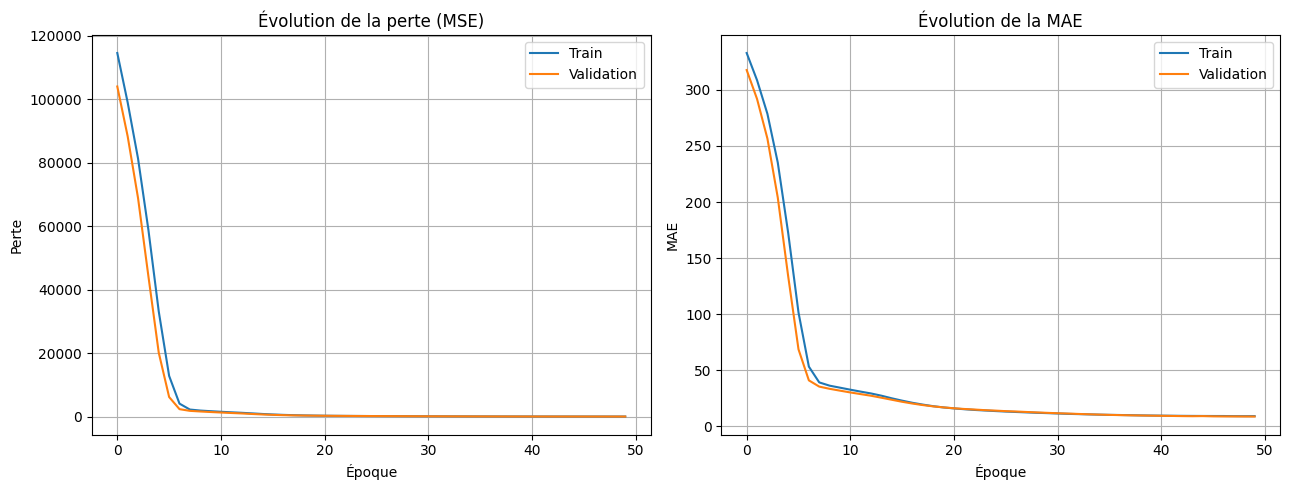

In [11]:
# 3) Visualisation de l'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Évolution de la perte (MSE)")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Perte")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["mae"], label="Train")
axes[1].plot(history.history["val_mae"], label="Validation")
axes[1].set_title("Évolution de la MAE")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Interprétation :** la perte et la MAE diminuent rapidement puis se stabilisent, aussi bien sur le train que sur la validation — signe que le modèle apprend correctement **sans sur-apprentissage majeur** (les deux courbes restent proches ; un écart important entre elles indiquerait un surapprentissage).

## Partie 6 : Évaluation

`evaluate()` calcule la perte et la métrique sur des données **jamais vues** pendant l'entraînement — la mesure la plus fiable de la performance réelle du modèle.

In [12]:
# 1) Évaluation sur les données de test
resultat_test = modele.evaluate(X_test, y_test, verbose=0)
perte_test, mae_test = resultat_test

print(f"Perte (MSE) sur le test : {perte_test:.2f}")
print(f"Erreur absolue moyenne (MAE) sur le test : {mae_test:.2f}")


Perte (MSE) sur le test : 156.63
Erreur absolue moyenne (MAE) sur le test : 9.78


**2) Interprétation :** la MAE indique qu'en moyenne, la prédiction du modèle s'écarte de la vraie consommation d'environ cette valeur (dans la même unité que `consommation`). Comme le bruit ajouté à la génération des données avait un écart-type de 10, une MAE proche de cet ordre de grandeur signifie que le modèle a bien appris la relation sous-jacente, la marge d'erreur restante correspondant essentiellement au bruit aléatoire irréductible introduit dans les données.